In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [15]:
pip install bertopic


In [ ]:
!pip -q install bertopic sentence-transformers umap-learn hdbscan spacy
!python -m spacy download en_core_web_sm -q

import re
import numpy as np
import pandas as pd
from collections import Counter
import spacy
from tqdm.auto import tqdm
from bertopic import BERTopic


#  Load data + light cleaning
BASE_PATH = "/content/drive/MyDrive/nlp/final project/clean_base_dataset.csv"
df = pd.read_csv(BASE_PATH)
print("Loaded:", df.shape)
print(df.columns.tolist())

def light_clean(text: str) -> str:
    text = str(text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text_bt"] = df["clean_text"].fillna("").astype(str).apply(light_clean)

# Optional: filter very short docs for stability
MIN_CHARS = 200
df = df[df["text_bt"].str.len() >= MIN_CHARS].copy()

# Optional: sample to keep compute manageable
SAMPLE_N = 25000
RANDOM_STATE = 42
MAX_CHARS = 2000

df_model = df.sample(n=min(SAMPLE_N, len(df)), random_state=RANDOM_STATE).copy()
docs = [t[:MAX_CHARS] for t in df_model["text_bt"].tolist()]
print("df_model:", df_model.shape, "docs:", len(docs))


# Load BERTopic model + assign topics (NO re-fit)
MODEL_PATH = "/content/drive/MyDrive/nlp/final project/bertopic_model_sample.pkl"
topic_model = BERTopic.load(MODEL_PATH)
print("Loaded BERTopic:", MODEL_PATH)

topics, probs = topic_model.transform(docs)   # <-- key line (fast vs fit_transform)
df_model["topic_id"] = topics
print("Topic assignment done. Outliers:", (df_model["topic_id"] == -1).mean())


#  ORG extraction via spaCy NER
nlp_ner = spacy.load("en_core_web_sm", disable=["parser", "tagger", "lemmatizer"])
nlp_ner.enable_pipe("ner")

TITLE_CHARS = 220
BODY_CHARS = 350

df_model["ner_text"] = (
    df_model["title"].fillna("").astype(str).str[:TITLE_CHARS] + ". " +
    df_model["clean_text"].fillna("").astype(str).str[:BODY_CHARS]
)

def extract_orgs_batch(texts, batch_size=256):
    out = []
    for doc in tqdm(nlp_ner.pipe(texts, batch_size=batch_size), total=len(texts)):
        out.append([ent.text for ent in doc.ents if ent.label_ == "ORG"])
    return out

df_model["orgs_raw"] = extract_orgs_batch(df_model["ner_text"].tolist())

# Normalize org names a bit
SUFFIXES = {"inc", "inc.", "corp", "corp.", "corporation", "co", "co.", "ltd", "ltd.", "llc", "plc", "group", "holdings", "limited"}
GENERIC_REMOVE = {"AI", "Artificial Intelligence"}

def clean_org(name: str) -> str:
    s = re.sub(r"\s+", " ", str(name).strip())
    parts = s.split()
    while len(parts) > 1 and parts[-1].lower().strip(".") in {x.strip(".") for x in SUFFIXES}:
        parts = parts[:-1]
    s = " ".join(parts)
    if s in GENERIC_REMOVE:
        return ""
    return s

df_model["orgs"] = df_model["orgs_raw"].apply(lambda lst: [c for c in (clean_org(x) for x in lst) if c])

print("ORG extraction complete.")


# Technology extraction (rules + patterns)
#    (edit/extend TECH_KEYWORDS for your project)
TECH_KEYWORDS = [
    # foundation / model families
    "transformer", "bert", "gpt", "llm", "large language model", "diffusion",
    "stable diffusion", "midjourney", "dall-e", "imagen", "gemini", "claude",
    # methods
    "rag", "retrieval augmented generation", "fine-tuning", "finetuning", "lora", "qlora",
    "prompt engineering", "embeddings", "vector database", "semantic search",
    "reinforcement learning", "rlhf", "distillation",
    # infra / chips
    "gpu", "cuda", "tpu", "h100", "a100", "inference", "quantization",
    # enterprise
    "copilot", "chatbot", "agent", "agents", "agentic",
    # security/ops
    "phishing", "malware", "deepfake",
]

# simple regex patterns for common tech tokens
TECH_REGEXES = [
    r"\bGPT[- ]?\d(\.\d+)?\b",
    r"\bBERT\b",
    r"\bLLM(s)?\b",
    r"\bRAG\b",
    r"\bLoRA\b|\bQLoRA\b",
    r"\bCUDA\b",
    r"\bTPU(s)?\b",
    r"\bH100\b|\bA100\b",
    r"\bDiffusion\b",
    r"\bCopilot\b",
]

tech_kw_norm = [k.lower() for k in TECH_KEYWORDS]
tech_regex_compiled = [re.compile(pat, flags=re.IGNORECASE) for pat in TECH_REGEXES]

def extract_tech(text: str):
    t = str(text).lower()
    found = set()

    # keyword contains
    for kw in tech_kw_norm:
        if kw in t:
            found.add(kw)

    # regex hits (keep original-ish token form)
    raw = str(text)
    for rgx in tech_regex_compiled:
        for m in rgx.findall(raw):
            # findall may return tuples; normalize to string
            if isinstance(m, tuple):
                m = " ".join([x for x in m if x])
            m = str(m).strip()
            if m:
                found.add(m.lower())

    return sorted(found)

# run on ner_text (title + snippet) or full clean_text if you want more recall
df_model["tech_terms"] = df_model["ner_text"].apply(extract_tech)
print("Technology extraction complete.")


# Summaries: overall + by topic
# Overall top orgs
orgs_flat = [o for lst in df_model["orgs"] for o in lst]
overall_org = pd.DataFrame(Counter(orgs_flat).most_common(30), columns=["organization", "mention_count"])
display(overall_org.head(15))

# Overall top technologies
tech_flat = [x for lst in df_model["tech_terms"] for x in lst]
overall_tech = pd.DataFrame(Counter(tech_flat).most_common(30), columns=["technology", "mention_count"])
display(overall_tech.head(15))

# By topic: top orgs + tech
rows_org = []
rows_tech = []

for tid in sorted(df_model["topic_id"].unique()):
    if tid == -1:
        continue
    sub = df_model[df_model["topic_id"] == tid]

    orgs = [o for lst in sub["orgs"] for o in lst]
    techs = [x for lst in sub["tech_terms"] for x in lst]

    for org, cnt in Counter(orgs).most_common(15):
        rows_org.append({"topic_id": tid, "organization": org, "mention_count": cnt})

    for tech, cnt in Counter(techs).most_common(15):
        rows_tech.append({"topic_id": tid, "technology": tech, "mention_count": cnt})

topic_org_table = pd.DataFrame(rows_org).sort_values(["topic_id", "mention_count"], ascending=[True, False])
topic_tech_table = pd.DataFrame(rows_tech).sort_values(["topic_id", "mention_count"], ascending=[True, False])

display(topic_org_table.head(30))
display(topic_tech_table.head(30))


#  Save outputs

OUT_MODEL_DF = "/content/drive/MyDrive/nlp/final project/df_model_bertopic_topics_org_tech.csv"
OUT_ORG_OVERALL = "/content/drive/MyDrive/nlp/final project/top_orgs_overall.csv"
OUT_TECH_OVERALL = "/content/drive/MyDrive/nlp/final project/top_tech_overall.csv"
OUT_ORG_BY_TOPIC = "/content/drive/MyDrive/nlp/final project/top_orgs_by_topic.csv"
OUT_TECH_BY_TOPIC = "/content/drive/MyDrive/nlp/final project/top_tech_by_topic.csv"

df_model.to_csv(OUT_MODEL_DF, index=False)
overall_org.to_csv(OUT_ORG_OVERALL, index=False)
overall_tech.to_csv(OUT_TECH_OVERALL, index=False)
topic_org_table.to_csv(OUT_ORG_BY_TOPIC, index=False)
topic_tech_table.to_csv(OUT_TECH_BY_TOPIC, index=False)

print("Saved:", OUT_MODEL_DF)
print("Saved:", OUT_ORG_OVERALL)
print("Saved:", OUT_TECH_OVERALL)
print("Saved:", OUT_ORG_BY_TOPIC)
print("Saved:", OUT_TECH_BY_TOPIC)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 55.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Loaded: (196276, 6)
['url', 'date', 'title', 'clean_text', 'text_len', 'domain']
df_model: (25000, 7) docs: 25000
Loaded BERTopic: /content/drive/MyDrive/nlp/final project/bertopic_model_sample.pkl


Batches:   0%|          | 0/782 [00:00<?, ?it/s]

Topic assignment done. Outliers: 0.38484


  0%|          | 0/25000 [00:00<?, ?it/s]

ORG extraction complete.
Technology extraction complete.


,organization,mention_count
0,Microsoft,1330
1,Google,1042
2,Premium Photo,714
3,OpenAI,663
4,Navigation Search Please,599
5,Industry News,512
6,TextShare,511
7,Home News News,504
8,Apple,495
9,Region American Europe Arab World,455


,technology,mention_count
0,gpt,2354
1,rag,924
2,chatbot,543
3,agent,463
4,gpu,306
5,agents,201
6,lora,187
7,gemini,187
8,bert,163
9,llm,144


,topic_id,organization,mention_count
0,0,KindnessMedical MinuteTake,27
1,0,Digital,22
2,0,FirstHello,22
3,0,Road TripLocal Jobs Hiring NowGreat Health,19
4,0,ExpoDakota,19
5,0,NewscastLatest,19
6,0,UsClosings,19
7,0,CupThe,18
8,0,MapsStorm,17
9,0,Shop,17


,topic_id,technology,mention_count
0,0,rag,78
1,0,gpt,56
2,0,llm,20
3,0,chatbot,8
4,0,large language model,7
5,0,copilot,6
6,0,gpu,5
7,0,agent,5
8,0,deepfake,2
9,0,tpu,2


Saved: /content/drive/MyDrive/nlp/final project/df_model_bertopic_topics_org_tech.csv
Saved: /content/drive/MyDrive/nlp/final project/top_orgs_overall.csv
Saved: /content/drive/MyDrive/nlp/final project/top_tech_overall.csv
Saved: /content/drive/MyDrive/nlp/final project/top_orgs_by_topic.csv
Saved: /content/drive/MyDrive/nlp/final project/top_tech_by_topic.csv


**Don't have to rerun the models from here**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import re

BASE = "/content/drive/MyDrive/nlp/final project/"

org_overall = pd.read_csv(BASE + "top_orgs_overall.csv")
tech_overall = pd.read_csv(BASE + "top_tech_overall.csv")
org_by_topic = pd.read_csv(BASE + "top_orgs_by_topic.csv")
tech_by_topic = pd.read_csv(BASE + "top_tech_by_topic.csv")

display(org_overall.head())
display(tech_overall.head())

,organization,mention_count
0,Microsoft,1330
1,Google,1042
2,Premium Photo,714
3,OpenAI,663
4,Navigation Search Please,599


,technology,mention_count
0,gpt,2354
1,rag,924
2,chatbot,543
3,agent,463
4,gpu,306


In [3]:
import re

# Expanded manual blacklist (clear junk)
junk_orgs = {
    "Premium Photo",
    "Navigation Search Please",
    "Industry News",
    "TextShare",
    "Home News News",
    "Major News",
    "Region American Europe Arab World",
    "Invest",
    "GMT",
    "Trump"
}

def is_valid_org(name: str) -> bool:
    n = str(name).strip()
    n_low = n.lower()

    # Too short
    if len(n) < 3:
        return False

    # Remove obvious UI / crawl artifacts
    if re.search(r"(photo|search|navigation|subscribe|cookie|privacy|terms|newsletter)", n_low):
        return False

    # Remove generic news labels (keep real outlets optionally)
    if re.search(r"\bnews\b", n_low) and n_low not in {"bbc news", "cbs news", "sky news"}:
        return False

    # Remove region/menu labels
    if n_low.startswith("region "):
        return False

    # Remove time abbreviations
    if n_low in {"gmt", "est", "pst", "utc"}:
        return False

    # Remove generic financial words
    if n_low in {"invest", "investment", "fund", "market"}:
        return False

    # Remove single-word person-like names (capitalized first name only)
    if len(n.split()) == 1 and n.istitle() and len(n) > 3:
        # optional: allow known companies like Meta, Apple, Amazon, etc.
        allowed_single_words = {
            "Meta", "Apple", "Amazon", "Nasdaq", "Chevron",
            "Intel", "IBM", "Google", "Microsoft", "OpenAI"
        }
        if n not in allowed_single_words:
            return False

    # Remove long strange phrases
    if len(n.split()) > 5:
        return False

    return True


# Apply filters
org_clean = org_overall[
    (~org_overall["organization"].isin(junk_orgs)) &
    (org_overall["organization"].apply(is_valid_org))
].copy()

# Re-sort
org_clean = org_clean.sort_values("mention_count", ascending=False)

display(org_clean.head(20))

,organization,mention_count
0,Microsoft,1330
1,Google,1042
3,OpenAI,663
8,Apple,495
10,Amazon,407
13,Nasdaq,337
14,chevron,335
16,Meta,279
17,NBC,248
18,IBM,247


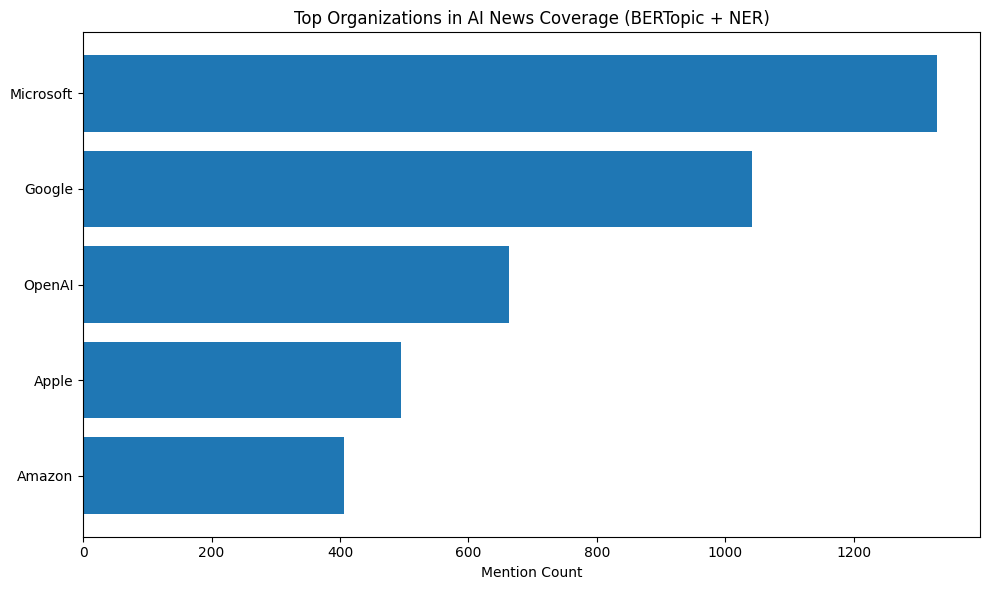

In [4]:
topN = 5

plot_df = org_clean.head(topN).sort_values("mention_count")

plt.figure(figsize=(10,6))
plt.barh(plot_df["organization"], plot_df["mention_count"])
plt.xlabel("Mention Count")
plt.title("Top Organizations in AI News Coverage (BERTopic + NER)")
plt.tight_layout()
plt.show()

**Clean organizations + re-plot by topic**

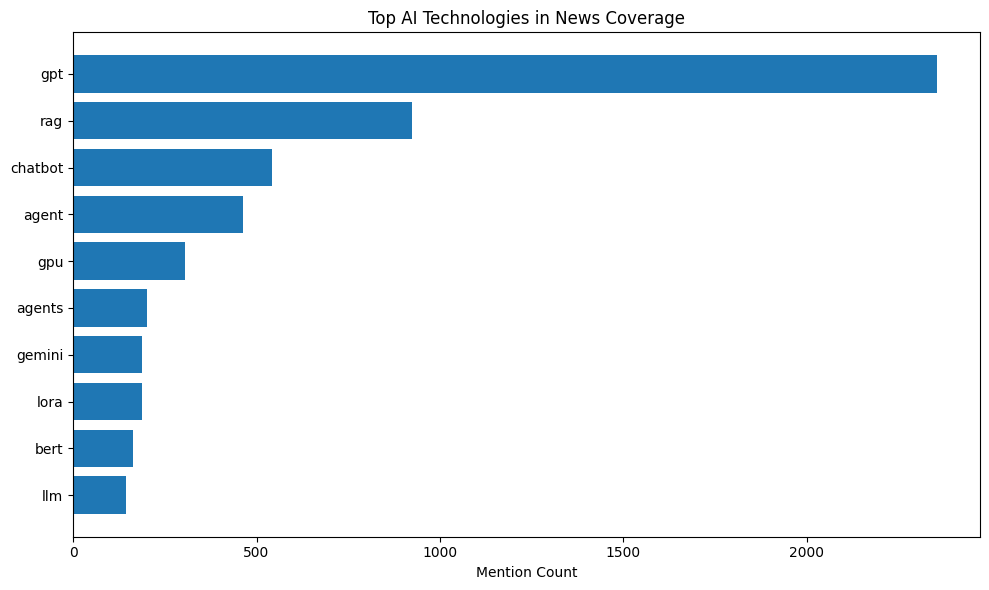

In [5]:
topN = 10
plot_df = tech_overall.head(topN).sort_values("mention_count")

plt.figure(figsize=(10,6))
plt.barh(plot_df["technology"], plot_df["mention_count"])
plt.xlabel("Mention Count")
plt.title("Top AI Technologies in News Coverage")
plt.tight_layout()
plt.show()

In [6]:
def norm(s: str) -> str:
    return re.sub(r"\s+", " ", str(s).lower()).strip()

INDUSTRY_RULES = [
    ("Enterprise IT & Digital Transformation", [
        "enterprise", "software", "saas", "cloud", "infrastructure", "deployment"
    ]),
    ("Generative AI Images & Creative Tools", [
        "image", "photo", "art", "midjourney", "diffusion", "adobe"
    ]),
    ("AI Chips & Financial Markets", [
        "chip", "gpu", "semiconductor", "nvidia", "amd", "intel", "nasdaq"
    ]),
    ("Healthcare & Clinical AI", [
        "clinical", "patient", "medical", "health", "hospital", "drug", "disease"
    ]),
    ("Finance & Investment", [
        "stock", "market", "trading", "investor", "fund", "earnings"
    ]),
    ("ChatGPT & AI Assistants", [
        "chatgpt", "gpt", "chatbot", "assistant", "copilot"
    ]),
    ("OpenAI & Big Tech AI Industry", [
        "openai", "microsoft", "google", "meta", "anthropic", "gemini"
    ]),
    ("Cybersecurity & AI Risk", [
        "security", "risk", "threat", "breach", "malware"
    ]),
]

In [7]:
import pandas as pd
import re

BASE = "/content/drive/MyDrive/nlp/final project/"
bertopic_table = pd.read_csv(BASE + "bertopic_table_sample.csv")

print("Columns:", bertopic_table.columns.tolist())
display(bertopic_table.head())

Columns: ['topic_id', 'count', 'top_words']


,topic_id,count,top_words
0,0,1495,"prnewswire, country music, 2023 prnewswire, dc..."
1,1,626,"donate, programs, air playing, npr, 00 00, sch..."
2,2,517,"entertain ment, ment, transportation, entertai..."
3,3,508,"gpt, chatgpt, chatbot, openai, users, chatbots..."
4,4,460,"cancer, disease, channels, drug, fierce, medic..."


In [8]:
def map_topic_to_industry(top_words: str):
    tw = norm(top_words)
    best_label = "Other / Mixed"
    best_hits = 0

    for label, keywords in INDUSTRY_RULES:
        hits = sum(1 for kw in keywords if kw in tw)
        if hits > best_hits:
            best_hits = hits
            best_label = label

    return best_label

bertopic_table["industry"] = bertopic_table["top_words"].apply(map_topic_to_industry)

display(bertopic_table.head(15))

,topic_id,count,top_words,industry
0,0,1495,"prnewswire, country music, 2023 prnewswire, dc...",Other / Mixed
1,1,626,"donate, programs, air playing, npr, 00 00, sch...",Other / Mixed
2,2,517,"entertain ment, ment, transportation, entertai...",Other / Mixed
3,3,508,"gpt, chatgpt, chatbot, openai, users, chatbots...",ChatGPT & AI Assistants
4,4,460,"cancer, disease, channels, drug, fierce, medic...",Healthcare & Clinical AI
5,5,400,"republic, congo, presswire, ein presswire, isl...",Other / Mixed
6,6,390,"oil energy, europe arab, asia africa, mena, ar...",Generative AI Images & Creative Tools
7,7,278,"india, minister, indian, india ai, modi, delhi...",Other / Mixed
8,8,275,"outdoors, rawpixel, px 300, jpeg, px, 300, ima...",Generative AI Images & Creative Tools
9,9,275,"galaxy, samsung, pixel, s24, samsung galaxy, g...",Generative AI Images & Creative Tools


In [10]:
df_model = bertopic_table.copy()

In [11]:
topic_to_industry = dict(
    zip(bertopic_table["topic_id"], bertopic_table["industry"])
)

df_model["industry"] = df_model["topic_id"].map(topic_to_industry)

# Handle outliers
df_model.loc[df_model["topic_id"] == -1, "industry"] = "Outlier / Unclustered"

print("Industry column added.")
print(df_model["industry"].value_counts().head(10))

Industry column added.
industry
Other / Mixed                             87
Generative AI Images & Creative Tools     26
AI Chips & Financial Markets              13
OpenAI & Big Tech AI Industry             13
Finance & Investment                       8
Healthcare & Clinical AI                   5
Enterprise IT & Digital Transformation     5
ChatGPT & AI Assistants                    3
Cybersecurity & AI Risk                    1
Name: count, dtype: int64


In [12]:
print("Null industries:", df_model["industry"].isna().sum())
display(df_model[["topic_id", "industry"]].head())

Null industries: 0


,topic_id,industry
0,0,Other / Mixed
1,1,Other / Mixed
2,2,Other / Mixed
3,3,ChatGPT & AI Assistants
4,4,Healthcare & Clinical AI


In [13]:
# 1) build mapping from topic_id -> industry
topic_to_industry = dict(
    zip(bertopic_table["topic_id"].astype(int), bertopic_table["industry"])
)

# 2) apply to df_model
df_model["industry"] = df_model["topic_id"].map(topic_to_industry)

# 3) handle outliers + missing
df_model.loc[df_model["topic_id"] == -1, "industry"] = "Outlier / Unclustered"
df_model["industry"] = df_model["industry"].fillna("Other / Mixed")

print("Industry column added.")
display(df_model["industry"].value_counts().head(15))
print("Null industries:", df_model["industry"].isna().sum())

Industry column added.


,count
industry,
Other / Mixed,87
Generative AI Images & Creative Tools,26
AI Chips & Financial Markets,13
OpenAI & Big Tech AI Industry,13
Finance & Investment,8
Healthcare & Clinical AI,5
Enterprise IT & Digital Transformation,5
ChatGPT & AI Assistants,3
Cybersecurity & AI Risk,1


Null industries: 0


In [14]:
!pip -q install bertopic sentence-transformers umap-learn hdbscan spacy
!python -m spacy download en_core_web_sm -q

import re
import numpy as np
import pandas as pd
from collections import Counter
import spacy
from tqdm.auto import tqdm
from bertopic import BERTopic


#  Load data + light cleaning
BASE_PATH = "/content/drive/MyDrive/nlp/final project/clean_base_dataset.csv"
df = pd.read_csv(BASE_PATH)
print("Loaded:", df.shape)
print(df.columns.tolist())

def light_clean(text: str) -> str:
    text = str(text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text_bt"] = df["clean_text"].fillna("").astype(str).apply(light_clean)

# Optional: filter very short docs for stability
MIN_CHARS = 200
df = df[df["text_bt"].str.len() >= MIN_CHARS].copy()

# Optional: sample to keep compute manageable
SAMPLE_N = 25000
RANDOM_STATE = 42
MAX_CHARS = 2000

df_model = df.sample(n=min(SAMPLE_N, len(df)), random_state=RANDOM_STATE).copy()
docs = [t[:MAX_CHARS] for t in df_model["text_bt"].tolist()]
print("df_model:", df_model.shape, "docs:", len(docs))


# Load BERTopic model + assign topics (NO re-fit)
MODEL_PATH = "/content/drive/MyDrive/nlp/final project/bertopic_model_sample.pkl"
topic_model = BERTopic.load(MODEL_PATH)
print("Loaded BERTopic:", MODEL_PATH)

topics, probs = topic_model.transform(docs)   # <-- key line (fast vs fit_transform)
df_model["topic_id"] = topics
print("Topic assignment done. Outliers:", (df_model["topic_id"] == -1).mean())


#  ORG extraction via spaCy NER
nlp_ner = spacy.load("en_core_web_sm", disable=["parser", "tagger", "lemmatizer"])
nlp_ner.enable_pipe("ner")

TITLE_CHARS = 220
BODY_CHARS = 350

df_model["ner_text"] = (
    df_model["title"].fillna("").astype(str).str[:TITLE_CHARS] + ". " +
    df_model["clean_text"].fillna("").astype(str).str[:BODY_CHARS]
)

def extract_orgs_batch(texts, batch_size=256):
    out = []
    for doc in tqdm(nlp_ner.pipe(texts, batch_size=batch_size), total=len(texts)):
        out.append([ent.text for ent in doc.ents if ent.label_ == "ORG"])
    return out

df_model["orgs_raw"] = extract_orgs_batch(df_model["ner_text"].tolist())

# Normalize org names a bit
SUFFIXES = {"inc", "inc.", "corp", "corp.", "corporation", "co", "co.", "ltd", "ltd.", "llc", "plc", "group", "holdings", "limited"}
GENERIC_REMOVE = {"AI", "Artificial Intelligence"}

def clean_org(name: str) -> str:
    s = re.sub(r"\s+", " ", str(name).strip())
    parts = s.split()
    while len(parts) > 1 and parts[-1].lower().strip(".") in {x.strip(".") for x in SUFFIXES}:
        parts = parts[:-1]
    s = " ".join(parts)
    if s in GENERIC_REMOVE:
        return ""
    return s

df_model["orgs"] = df_model["orgs_raw"].apply(lambda lst: [c for c in (clean_org(x) for x in lst) if c])

print("ORG extraction complete.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 10.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 117.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


Loaded: (196276, 6)
['url', 'date', 'title', 'clean_text', 'text_len', 'domain']
df_model: (25000, 7) docs: 25000
Loaded BERTopic: /content/drive/MyDrive/nlp/final project/bertopic_model_sample.pkl


Batches:   0%|          | 0/782 [00:00<?, ?it/s]

Topic assignment done. Outliers: 0.3846


  0%|          | 0/25000 [00:00<?, ?it/s]

ORG extraction complete.


In [16]:
SAVE_PATH_FULL = "/content/drive/MyDrive/nlp/final project/ai_news_bertopic_ner_entities.csv"

df_model.to_csv(SAVE_PATH_FULL, index=False)

print("Saved to:", SAVE_PATH_FULL)

Saved to: /content/drive/MyDrive/nlp/final project/ai_news_bertopic_ner_entities.csv


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# ----------------------------
# 0) sanity checks
# ----------------------------
required_cols = ["industry", "orgs", "tech_terms"]
missing = [c for c in required_cols if c not in df_model.columns]
if missing:
    raise KeyError(f"df_model is missing columns: {missing}. Current cols: {df_model.columns.tolist()}")

print("df_model shape:", df_model.shape)
print("industry value counts (top 10):")
print(df_model["industry"].value_counts().head(10))

# ----------------------------
# 1) Build long tables: ORGs + Tech by industry
# ----------------------------
NOISE_INDUSTRIES = {
    "Outlier / Unclustered",
    "Other / Mixed",
    "Newswire / Distribution (noise)",
    "Broadcast / Radio / Programming (noise)",
    "Non-English / Mixed (noise)",
    "Entertainment / Media (noise)",
    "Local News / Weather (noise)",
}

df_use = df_model[~df_model["industry"].isin(NOISE_INDUSTRIES)].copy()

# explode ORGs
org_long = (
    df_use[["industry", "orgs"]]
    .explode("orgs")
    .rename(columns={"orgs": "organization"})
)
org_long["organization"] = org_long["organization"].fillna("").astype(str).str.strip()
org_long = org_long[org_long["organization"] != ""]

# explode Tech terms
tech_long = (
    df_use[["industry", "tech_terms"]]
    .explode("tech_terms")
    .rename(columns={"tech_terms": "technology"})
)
tech_long["technology"] = tech_long["technology"].fillna("").astype(str).str.strip()
tech_long = tech_long[tech_long["technology"] != ""]

# aggregate counts
org_by_industry = (
    org_long.groupby(["industry", "organization"])
    .size()
    .reset_index(name="mention_count")
    .sort_values(["industry", "mention_count"], ascending=[True, False])
)

tech_by_industry = (
    tech_long.groupby(["industry", "technology"])
    .size()
    .reset_index(name="mention_count")
    .sort_values(["industry", "mention_count"], ascending=[True, False])
)

print("org_by_industry:", org_by_industry.shape, "tech_by_industry:", tech_by_industry.shape)
display(org_by_industry.head(10))
display(tech_by_industry.head(10))

# save (optional)
org_by_industry.to_csv("/content/drive/MyDrive/nlp/final project/top_orgs_by_industry.csv", index=False)
tech_by_industry.to_csv("/content/drive/MyDrive/nlp/final project/top_tech_by_industry.csv", index=False)
print("Saved: top_orgs_by_industry.csv, top_tech_by_industry.csv")

# ----------------------------
# 2) Pick top industries by volume (excludes noise)
# ----------------------------
industry_counts = df_use["industry"].value_counts()
top_industries = industry_counts.head(4).index.tolist()
print("Top industries:", top_industries)

# ----------------------------
# 3) Plot helpers
# ----------------------------
def plot_top_entities_grid(df_table, entity_col, industries, topn=8, ncols=2, fig_title=""):
    n = len(industries)
    nrows = int(np.ceil(n / ncols))
    plt.figure(figsize=(14, 4.8 * nrows))

    for i, ind in enumerate(industries, start=1):
        sub = df_table[df_table["industry"] == ind].head(topn).sort_values("mention_count", ascending=True)

        ax = plt.subplot(nrows, ncols, i)
        ax.barh(sub[entity_col], sub["mention_count"])
        ax.set_title(f"{ind}", fontsize=12)
        ax.set_xlabel("Mention Count")
        ax.grid(axis="x", alpha=0.3)

    plt.suptitle(fig_title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# ----------------------------
# 4) Plot: ORGs by industry (top 4 industries)
# ----------------------------
plot_top_entities_grid(
    org_by_industry, "organization", top_industries, topn=8, ncols=2,
    fig_title="Top Organizations by Industry (BERTopic industry mapping + spaCy ORG)"
)

# ----------------------------
# 5) Plot: Tech by industry (top 4 industries)
# ----------------------------
plot_top_entities_grid(
    tech_by_industry, "technology", top_industries, topn=8, ncols=2,
    fig_title="Top AI Technologies by Industry (rule/regex extraction)"
)

# ----------------------------
# 6) Optional: overall top ORGs + overall top Tech
# ----------------------------
overall_org = (
    org_long["organization"].value_counts().head(15).sort_values(ascending=True)
)
plt.figure(figsize=(10, 6))
plt.barh(overall_org.index, overall_org.values)
plt.title("Top Organizations in AI News Coverage (BERTopic + NER)")
plt.xlabel("Mention Count")
plt.tight_layout()
plt.show()

overall_tech = (
    tech_long["technology"].value_counts().head(15).sort_values(ascending=True)
)
plt.figure(figsize=(10, 6))
plt.barh(overall_tech.index, overall_tech.values)
plt.title("Top AI Technologies in News Coverage")
plt.xlabel("Mention Count")
plt.tight_layout()
plt.show()

KeyError: "df_model is missing columns: ['industry', 'tech_terms']. Current cols: ['url', 'date', 'title', 'clean_text', 'text_len', 'domain', 'text_bt', 'topic_id', 'ner_text', 'orgs_raw', 'orgs']"

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Top 10 organizations overall (from df_use)
top_orgs = (
    org_long["organization"]
    .value_counts()
    .head(10)
    .index.tolist()
)

# Build pivot table: industry × organization
org_pivot = (
    org_long[org_long["organization"].isin(top_orgs)]
    .groupby(["industry", "organization"])
    .size()
    .reset_index(name="mention_count")
    .pivot(index="organization", columns="industry", values="mention_count")
    .fillna(0)
)

# Ensure consistent industry order
org_pivot = org_pivot[top_industries]

plt.figure(figsize=(12,6))

for ind in top_industries:
    plt.plot(org_pivot.index, org_pivot[ind], marker='o', label=ind)

plt.xticks(rotation=45, ha='right')
plt.ylabel("Mention Count")
plt.title("Top Organizations Across Industries")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'org_long' is not defined

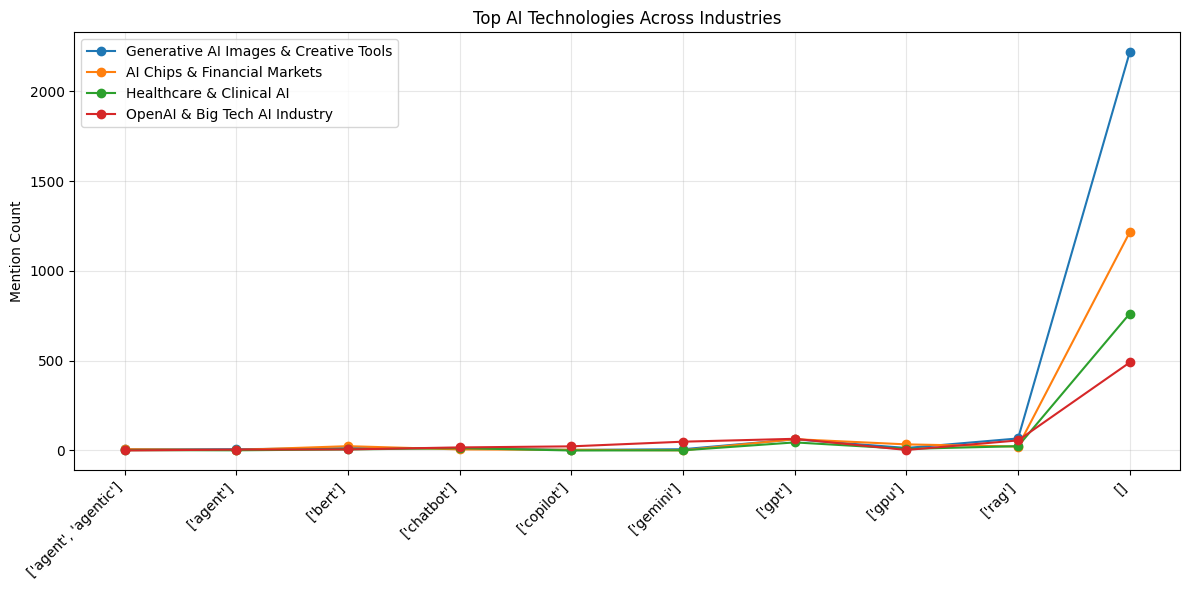

In [ ]:
# Top 10 technologies overall
top_tech = (
    tech_long["technology"]
    .value_counts()
    .head(10)
    .index.tolist()
)

# Pivot table
tech_pivot = (
    tech_long[tech_long["technology"].isin(top_tech)]
    .groupby(["industry", "technology"])
    .size()
    .reset_index(name="mention_count")
    .pivot(index="technology", columns="industry", values="mention_count")
    .fillna(0)
)

tech_pivot = tech_pivot[top_industries]

plt.figure(figsize=(12,6))

for ind in top_industries:
    plt.plot(tech_pivot.index, tech_pivot[ind], marker='o', label=ind)

plt.xticks(rotation=45, ha='right')
plt.ylabel("Mention Count")
plt.title("Top AI Technologies Across Industries")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Rebuild tech_long cleanly
tech_long = (
    df_use[["industry", "tech_terms"]]
    .explode("tech_terms")
    .rename(columns={"tech_terms": "technology"})
)

# Clean technology column
tech_long["technology"] = tech_long["technology"].astype(str).str.strip()

# Remove invalid values
tech_long = tech_long[
    (tech_long["technology"] != "") &
    (tech_long["technology"].notna()) &
    (tech_long["technology"] != "[]") &
    (tech_long["technology"] != "nan")
]

print("Clean tech_long shape:", tech_long.shape)
display(tech_long.head())

Clean tech_long shape: (1603, 2)


,industry,technology
7,Generative AI Images & Creative Tools,['gpt']
47,AI Chips & Financial Markets,['lora']
49,ChatGPT & AI Assistants,['gpt']
63,ChatGPT & AI Assistants,"['gpt', 'malware']"
68,ChatGPT & AI Assistants,['gpt']


In [ ]:
# Ensure technology column is pure string (not list)
tech_long["technology"] = tech_long["technology"].apply(
    lambda x: x[0] if isinstance(x, list) else x
)

# Convert to clean string
tech_long["technology"] = tech_long["technology"].astype(str)

# Optional: strip stray brackets if they were saved as strings like "['gpt']"
tech_long["technology"] = tech_long["technology"].str.replace(r"[\[\]']", "", regex=True).str.strip()

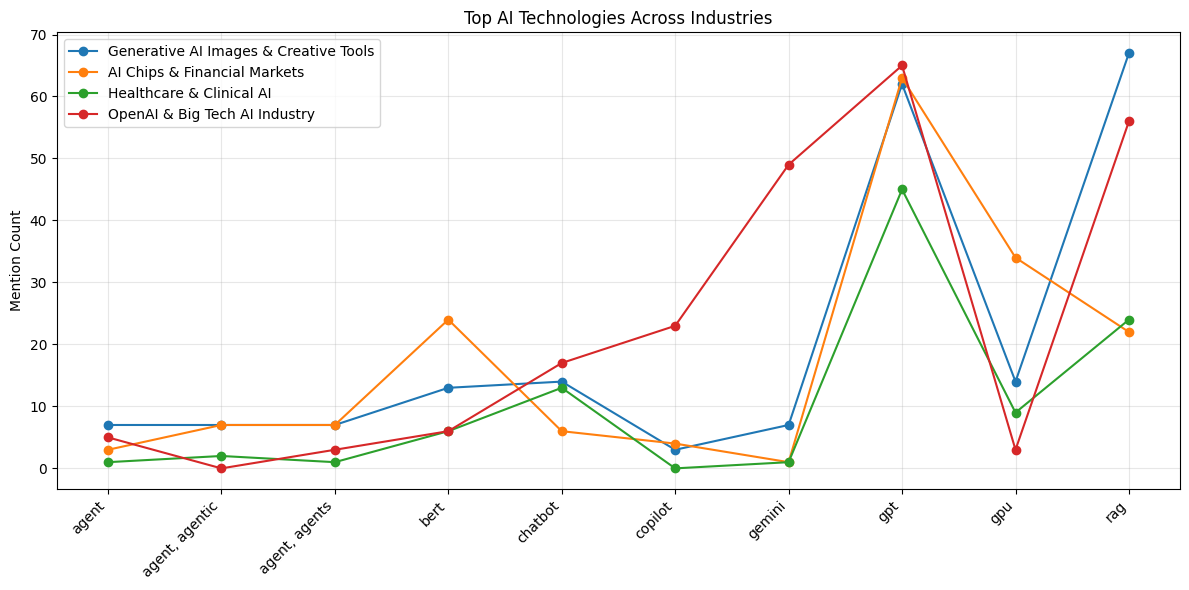

In [ ]:
# Recompute top technologies
top_tech = (
    tech_long["technology"]
    .value_counts()
    .head(10)
    .index.tolist()
)

tech_pivot = (
    tech_long[tech_long["technology"].isin(top_tech)]
    .groupby(["industry", "technology"])
    .size()
    .reset_index(name="mention_count")
    .pivot(index="technology", columns="industry", values="mention_count")
    .fillna(0)
)

tech_pivot = tech_pivot[top_industries]

plt.figure(figsize=(12,6))

for ind in top_industries:
    plt.plot(tech_pivot.index, tech_pivot[ind], marker='o', label=ind)

plt.xticks(rotation=45, ha='right')
plt.ylabel("Mention Count")
plt.title("Top AI Technologies Across Industries")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

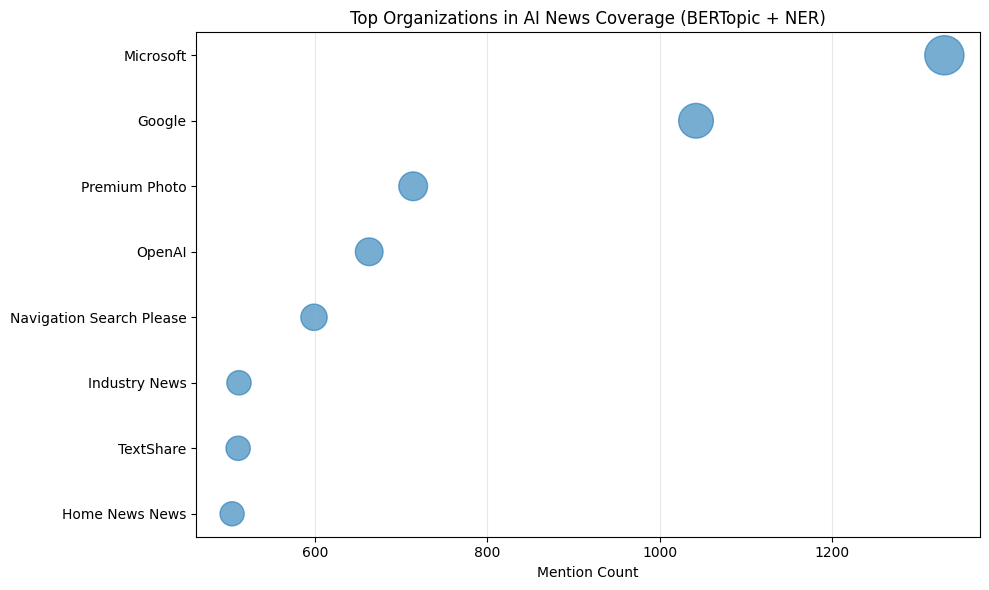

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

topN = 8

plot_df = org_overall.head(topN).sort_values("mention_count")

plt.figure(figsize=(10,6))

# Normalize bubble sizes for better scaling
sizes = plot_df["mention_count"]
size_scale = 0.6  # adjust if bubbles are too large/small
bubble_sizes = sizes * size_scale

y_positions = np.arange(len(plot_df))

plt.scatter(
    plot_df["mention_count"],
    y_positions,
    s=bubble_sizes,
    alpha=0.6
)

plt.yticks(y_positions, plot_df["organization"])
plt.xlabel("Mention Count")
plt.title("Top Organizations in AI News Coverage (BERTopic + NER)")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

for i, count in enumerate(plot_df["mention_count"]):
    plt.text(count, i, str(count),
             va='center', ha='center', fontsize=9, color='black')